### Завдання 1. Токенізація тексту
- Опис:
    - Дано невеликий текст (речення або відгуки).
    - Необхідно розбити його на слова (токени).
- Приклад даних:
    - "Кава дуже смачна, обслуговування на висоті."
- Очікуваний результат:
    - ['кава', 'дуже', 'смачна', ',', 'обслуговування', 'на', 'висоті', '.']

In [4]:
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')

reviews = [
    "Кава дуже смачна, обслуговування на висоті",
    "Чекав замовлення понад годину, дуже розчарований",
    "Місце затишне, напої чудові",
    "Кава холодна і несмачна"
]

tokenized_reviews = [word_tokenize(review.lower()) for review in reviews]

print("Токенізовані відгуки:", tokenized_reviews) # Виводимо результат на екран.

# --- Почнемо навчання моделі ---
# Створимо модель Word2Vec.
model = Word2Vec(sentences=tokenized_reviews, vector_size=50, window=3, min_count=1, workers=2, sg=1)

# Просимо модель знайти 3 слова, найбільш схожих за контекстом на слово "кава".
similar_words = model.wv.most_similar("кава", topn=3)

print("\nСлова, схожі на 'кава':")
# Виводимо результат.
for word, score in similar_words:
    print(f"{word} → схожість: {score:.2f}")

Токенізовані відгуки: [['кава', 'дуже', 'смачна', ',', 'обслуговування', 'на', 'висоті'], ['чекав', 'замовлення', 'понад', 'годину', ',', 'дуже', 'розчарований'], ['місце', 'затишне', ',', 'напої', 'чудові'], ['кава', 'холодна', 'і', 'несмачна']]

Слова, схожі на 'кава':
чудові → схожість: 0.23
понад → схожість: 0.15
смачна → схожість: 0.12


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Завдання 2. Лемматизація
- Опис:
    - Використовуючи лемматизатор (NLTK, pymorphy2 для української), звести слова до базової форми.
- Приклад:
    - ['біжить', 'бігли', 'бігати'] → ['бігти', 'бігти', 'бігти']

In [1]:
import stanza

# Одноразово завантажимо модель для української мови.
stanza.download('uk')

# Створимо конвеєр (pipeline) для обробки українського тексту.
nlp = stanza.Pipeline(lang='uk', processors='tokenize,lemma')

# Наші слова об'єднаємо в одне речення.
words = ['біжить', 'бігли', 'бігати', 'котами', 'найсильніший']
text = " ".join(words) 

# Опрацюємо текст за допомогою конвеєра.
doc = nlp(text)

print("Лемматизовані слова (stanza):")
# Пройдемо по кожному слову в обробленому документі.
for sent in doc.sentences:
    for word in sent.words:
        # Виведемо початковий текст слова та його лему.
        print(f"{word.text} → {word.lemma}")

2025-10-13 20:21:17 INFO: Downloaded file to C:\Users\User\stanza_resources\resources.json
2025-10-13 20:21:17 INFO: Downloading default packages for language: uk (Ukrainian) ...


2025-10-13 20:23:42 INFO: Downloaded file to C:\Users\User\stanza_resources\uk\default.zip
2025-10-13 20:23:45 INFO: Finished downloading models and saved to C:\Users\User\stanza_resources
2025-10-13 20:23:45 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2025-10-13 20:23:46 INFO: Downloaded file to C:\Users\User\stanza_resources\resources.json
2025-10-13 20:23:46 WARNING: Language uk package default expects mwt, which has been added
2025-10-13 20:23:46 INFO: Loading these models for language: uk (Ukrainian):
| Processor | Package     |
---------------------------
| tokenize  | iu          |
| mwt       | iu          |
| lemma     | iu_nocharlm |

2025-10-13 20:23:46 INFO: Using device: cpu
2025-10-13 20:23:46 INFO: Loading: tokenize
2025-10-13 20:23:47 INFO: Loading: mwt
2025-10-13 20:23:47 INFO: Loading: lemma
2025-10-13 20:23:48 INFO: Done loading processors!


Лемматизовані слова (stanza):
біжить → бігти
бігли → бігти
бігати → бігати
котами → котами
найсильніший → найсильніший


### Завдання 3.Стеммінг
- Опис:
    - Використати стеммер (наприклад, PorterStemmer для англійської) для обрізання закінчень слів.
- Приклад:
    - ['running', 'runs', 'ran'] → ['run', 'run', 'ran']

In [5]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
words = ['running', 'ran', 'runs', 'easily', 'fairly']
stemmed_words = [stemmer.stem(word) for word in words]
print("Stemmed words:", stemmed_words)

Stemmed words: ['run', 'ran', 'run', 'easili', 'fairli']


### Завдання 4. Видалення стоп-слів
- Опис:
    - Видалити з тексту слова, що не несуть смислового навантаження.
- Приклад:
    - "Я дуже люблю пити каву вранці" → ['люблю', 'пити', 'каву', 'вранці']

In [2]:
# Завантажимо список українських стоп-слів
stop_words_ua = [
    'а', 'але', 'без', 'був', 'була', 'були', 'було', 'вам', 'вас', 'весь',
    'вже', 'ви', 'від', 'він', 'вона', 'вони', 'воно', 'все', 'всі', 'всього',
    'де', 'до', 'дуже', 'є', 'за', 'з', 'і', 'із', 'інших', 'їх', 'й', 'його',
    'її', 'коли', 'кожен', 'може', 'мій', 'ми', 'на', 'навіть', 'нам', 'нас',
    'не', 'немає', 'ні', 'ній', 'ніхто', 'ніщо', 'ось', 'під', 'по', 'при',
    'про', 'раз', 'та', 'там', 'те', 'тебе', 'тим', 'то', 'тобто', 'того',
    'той', 'тому', 'тут', 'ти', 'у', 'хто', 'це', 'цей', 'чи', 'чого', 'чому',
    'щоб', 'що', 'як', 'який', 'я', 'і'
]

text = "Я дуже люблю пити каву вранці"
# Токенізуємо та переводимо в нижній регістр
tokenized_text = text.lower().split()

# Створимо новий список, куди додаємо лише ті слова, яких НЕМАЄ у списку stop_words_ua
filtered_words = [word for word in tokenized_text if word not in stop_words_ua]

print("Оригінальний токенізований текст:", tokenized_text)
print("Текст після видалення стоп-слів:", filtered_words)

Оригінальний токенізований текст: ['я', 'дуже', 'люблю', 'пити', 'каву', 'вранці']
Текст після видалення стоп-слів: ['люблю', 'пити', 'каву', 'вранці']


### Завдання 5. Побудова локальних embeddings із Word2Vec
- Опис:
    - Дано 10-20 коротких речень українською.
    - Створити модель Word2Vec і знайти топ-3 слів, схожих на “кава”.
- Приклад даних:
    - ["Кава смачна", "Напої чудові", "Чекав замовлення"]

In [1]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

# Одноразово завантажимо токенізатор
#nltk.download('punkt')

# 1. Напишемо приклад даних (10 речень)
reviews = [
    "Ця кава дуже смачна, мені сподобалось.",
    "Чудові напої та гарний сервіс.",
    "Кава була холодна, а десерт старий.",
    "Я люблю еспресо, це мій улюблений напій.",
    "Чай також був смачний.",
    "Замовив каву і тістечко, все супер.",
    "Дуже ароматний напій, рекомендую.",
    "Цей заклад пропонує каву та інші гарячі напої.",
    "Смачний лате, але обслуговування повільне.",
    "Непогана кава, але нічого особливого."
]

# 2. Проведемо токенізацію (перетворюємо речення на списки слів)
tokenized_reviews = [word_tokenize(review.lower()) for review in reviews]

# 3. Створимо та навчемо модель Word2Vec
model = Word2Vec(sentences=tokenized_reviews, vector_size=50, window=3, min_count=1, workers=4, sg=1)

# 4. Проведемо пошук слів, схожих на "кава"
try:
    similar_words = model.wv.most_similar("кава", topn=3)
    print("Топ-3 слів, схожих на 'кава':")
    for word, score in similar_words:
        print(f"{word} → схожість: {score:.2f}")
except KeyError:
    print("Слово 'кава' відсутнє у словнику моделі.")

Топ-3 слів, схожих на 'кава':
заклад → схожість: 0.25
пропонує → схожість: 0.25
замовив → схожість: 0.20


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Завдання 6. Використання GloVe для англійського тексту
- Опис:
    - Завантажити готовий файл GloVe (наприклад, glove.6B.50d.txt).
    - Знайти слова, схожі на “coffee” та “tea”.

In [3]:
from gensim.models import KeyedVectors

glove_file = r'DataSet\glove.6B.50d.txt'
# glove_file = 'DataSet/glove.6B.50d.txt'

# Завантажимо вектори. 
glove_model = KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)

# --- Пошук для "coffee" ---
similar_to_coffee = glove_model.most_similar("coffee", topn=3)
print("Слова, схожі на 'coffee' (GloVe):")
for word, score in similar_to_coffee:
    print(f"{word} → схожість: {score:.2f}")

# --- Пошук для "tea"  ---
similar_to_tea = glove_model.most_similar("tea", topn=3)
print("\nСлова, схожі на 'tea' (GloVe):")
for word, score in similar_to_tea:
    print(f"{word} → схожість: {score:.2f}")

Слова, схожі на 'coffee' (GloVe):
drink → схожість: 0.82
drinks → схожість: 0.82
wine → схожість: 0.81

Слова, схожі на 'tea' (GloVe):
coffee → схожість: 0.81
drinks → схожість: 0.77
drink → схожість: 0.76


### Завдання 7. Векторизація речень
- Опис:
    - Взяти речення і обчислити середній вектор всіх слів, щоб отримати представлення речення.
- Приклад:
    - "Кава смачна і гаряча"
- Слово "кава" → [0.2, 0.1, ...], "смачна" → [0.3, 0.0, ...]
- Результат → усереднене значення векторів

In [2]:
import numpy as np
from gensim.models import KeyedVectors

glove_file = r'DataSet/glove.6B.50d.txt'
try:
    glove_model = KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)
    print("Модель GloVe успішно завантажена.")
except FileNotFoundError:
    print(f"Помилка: файл '{glove_file}' не знайдено. Перевірте шлях.")
    glove_model = None

# --- Створимо функцію для векторизації речення ---
def sentence_to_vector(sentence, model):
    # Розібємо речення на слова, переводимо в нижній регістр
    words = sentence.lower().split()
    
    # Створимо список векторів для слів, які є в моделі
    word_vectors = [model[word] for word in words if word in model]
    
    if not word_vectors:
        return np.zeros(model.vector_size)
    
    # Обчислимо середнє значення по стовпцях (axis=0)
    sentence_vector = np.mean(word_vectors, axis=0)
    return sentence_vector

# --- Використання ---
if glove_model:
    sentence = "Coffee is tasty and hot" # Використаємо англійську, бо модель англомовна
    
    # Отримаємо вектор речення
    vector = sentence_to_vector(sentence, glove_model)

    print(f"\nРечення: '{sentence}'")
    print(f"Розмірність отриманого вектора: {vector.shape}")
    print("Приклад перших 5 компонент вектора:", vector[:5])

Модель GloVe успішно завантажена.

Речення: 'Coffee is tasty and hot'
Розмірність отриманого вектора: (50,)
Приклад перших 5 компонент вектора: [ 0.08367001  0.214344   -0.50020754  0.0819894   0.31026602]


### Завдання 8. Пошук схожих слів у реченнях
- Опис:
    - Для кожного слова у реченні знайти 2-3 найбільш схожих слова за Word2Vec.
- Приклад:
    - Речення: "Кава смачна"
    - Слово: "кава" → схожі: ['напій', 'чай', 'капучино']

In [3]:
from gensim.models import KeyedVectors

glove_file = r'DataSet/glove.6B.50d.txt'
try:
    glove_model = KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)
    print("Модель GloVe успішно завантажена.")
except FileNotFoundError:
    print(f"Помилка: файл '{glove_file}' не знайдено. Перевірте шлях.")
    glove_model = None

if glove_model:
    sentence = "Tasty coffee and hot tea"
    
    # Токенізуємо речення (простим поділом по пробілу)
    words = sentence.lower().split()
    print(f"\nАналізуємо речення: '{sentence}'\n")

    # Проходимо по кожному слову в реченні
    for word in words:
        # Перевіримо, чи є слово у словнику моделі
        if word in glove_model:
            # Знаходимо топ-3 схожих слів
            similar_words = glove_model.most_similar(word, topn=3)
            
            # Форматуємо результат для красивого виводу
            similar_str = ", ".join([f"{w} ({s:.2f})" for w, s in similar_words])
            print(f"Слово: '{word}' → Схожі: [{similar_str}]")
        else:
            print(f"Слово: '{word}' → Не знайдено у словнику моделі.")

Модель GloVe успішно завантажена.

Аналізуємо речення: 'Tasty coffee and hot tea'

Слово: 'tasty' → Схожі: [delicious (0.93), savory (0.85), flavorful (0.84)]
Слово: 'coffee' → Схожі: [drink (0.82), drinks (0.82), wine (0.81)]
Слово: 'and' → Схожі: [well (0.94), with (0.93), both (0.93)]
Слово: 'hot' → Схожі: [cool (0.86), cold (0.80), mix (0.77)]
Слово: 'tea' → Схожі: [coffee (0.81), drinks (0.77), drink (0.76)]


### Завдання 9. Аналіз тональності коротких відгуків
- Опис:
    - Дано 5-10 відгуків (позитивні і негативні).
    - Створити embedding для кожного відгуку (усереднити вектори слів).
    - Навчити просту модель (логістична регресія) для класифікації настрою.

In [2]:
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
import numpy as np
from nltk.tokenize import word_tokenize
import nltk
# nltk.download('punkt') # уже завантажував

# --- Наші дані ---
reviews = [
    "Кава чудова і дуже смачний десерт", "Найкраще місце для сніданку",
    "Обслуговування на висоті", "Дуже затишна атмосфера",
    "Смачні круасани та кава", "Чекав замовлення годину",
    "Їжа була холодна і несмачна", "Жахливий сервіс",
    "Повне розчарування", "Ціни високі а порції маленькі"
]
labels = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])
tokenized_reviews = [word_tokenize(review.lower()) for review in reviews]

# --- Навчимо власну маленьку модель Word2Vec ---
local_model = Word2Vec(sentences=tokenized_reviews, vector_size=50, window=3, min_count=1, sg=1)
print("Локальну модель Word2Vec навчено.")

# --- Створимо функцію для векторизації ---
def sentence_to_vector_local(sentence, model):
    words = sentence.lower().split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if not word_vectors:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)

# --- Проведемо векторизацію відгуків ---
X = np.array([sentence_to_vector_local(review, local_model) for review in reviews])
y = labels

# --- Проведемо навчання моделі логістичної регресії ---
classifier = LogisticRegression(random_state=42)
classifier.fit(X, y)

# --- Перевіремо моделі ---
new_review = "Приємна кава і сервіс"
vec = sentence_to_vector_local(new_review, local_model).reshape(1, -1)
prediction = classifier.predict(vec)
print(f"\nВідгук: '{new_review}' → Прогноз: {'Позитивний' if prediction[0] == 1 else 'Негативний'}")

Локальну модель Word2Vec навчено.

Відгук: 'Приємна кава і сервіс' → Прогноз: Позитивний


### Завдання 10. Візуалізація embeddings
- Опис:
    - Використати TSNE або PCA, щоб спроєктувати 50-розмірні вектори слів у 2D.
    - Візуалізувати слова на графіку, щоб побачити, які слова розташовані близько.

Локальну модель Word2Vec успішно навчено на нашому корпусі.


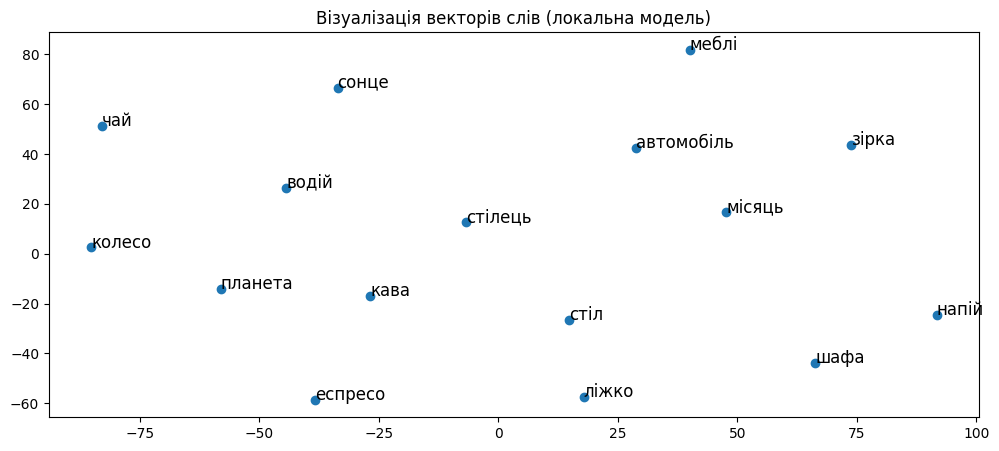

In [7]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import nltk

# Одноразово завантажимо токенізатор
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# --- Крок 1: Створимо власний міні-набір текстів ---
corpus = [
    "Смачна кава та ароматний чай з молоком.",
    "Водій веде автомобіль по дорозі.",
    "За столом стоїть стілець та велика шафа.",
    "Вночі на небі світить місяць і далека зірка.",
    "Мій улюблений напій – це еспресо з молоком.",
    "Водій зупинив машину біля дороги, щоб замінити колесо.",
    "У кімнаті стоїть ліжко, стіл та інші меблі.",
    "Сонце – це найяскравіша зірка на нашому небі.",
    "Планета земля обертається навколо сонця.",
    "Водій п'є гарячий чай за столом.",
    "Кава – популярний напій у всьому світі.",
    "Нові меблі, стілець та ліжко, привезли на машині."
]

# Проведемо токенізацію нашого набору
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

# --- Крок 2: Проведемо навчання власної локальної моделі Word2Vec ---
local_model = Word2Vec(sentences=tokenized_corpus, vector_size=50, window=3, min_count=1, workers=4)
print("Локальну модель Word2Vec успішно навчено на нашому корпусі.")

# --- Крок 3: Проведемо вибір слів для візуалізації та отримання їх векторів ---
words_to_visualize = [
    'кава', 'чай', 'молоко', 'еспресо', 'напій',
    'автомобіль', 'дорога', 'колесо', 'водій', 'машина',
    'стіл', 'стілець', 'шафа', 'ліжко', 'меблі',
    'сонце', 'місяць', 'зірка', 'небо', 'планета'
]

# Вибиремо тільки ті слова, які є в нашій моделі
valid_words = [word for word in words_to_visualize if word in local_model.wv]
word_vectors = np.array([local_model.wv[word] for word in valid_words])

# --- Крок 4: Зменшимо розмірності за допомогою t-SNE ---
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
vectors_2d = tsne.fit_transform(word_vectors)

# --- Крок 5: Візуалізуємо результати ---
plt.figure(figsize=(12, 5))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(valid_words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=12)

plt.title("Візуалізація векторів слів (локальна модель)")
plt.show()